# Initial Data Exploration (EDA)

Thai marketplace scrape of health & wellness supplements. **Modeling target: `Price`** (regression from `Section`, `Name`, `Shop Location`).

This notebook profiles the raw dataset, surfaces data-quality issues (quoted fields with commas, ฿-prefixed prices, mostly-empty sold/reviews, Thai-text sold counts), and gives a first read on which features carry price signal.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

DATA = Path('../dataset/health_and_wellness_cleaned_20230810_213000.csv')
FIGS = Path('figures')
FIGS.mkdir(exist_ok=True)

df = pd.read_csv(DATA)
df.shape, df.dtypes.to_dict()

((68499, 7),
 {'Id': dtype('int64'),
  'Section': <StringDtype(storage='python', na_value=nan)>,
  'Name': <StringDtype(storage='python', na_value=nan)>,
  'Price': <StringDtype(storage='python', na_value=nan)>,
  'Total Sold': <StringDtype(storage='python', na_value=nan)>,
  'Total Reviews': <StringDtype(storage='python', na_value=nan)>,
  'Shop Location': <StringDtype(storage='python', na_value=nan)>})

## 1. Load & sanity

A naive comma-split breaks on `"Stress, Sleep, and Anxiety"` and on the 3,441 product names that contain commas. `pd.read_csv` handles quoting natively — sanity asserts confirm the artifact is gone.

In [2]:
assert df.shape[0] == 68499, df.shape
assert (df['Section'] == 'Stress').sum() == 0, 'comma-split artifact survived'
assert (df['Section'] == 'Stress, Sleep, and Anxiety').sum() == 640
assert df['Name'].astype(str).str.contains(',').sum() == 3441
print('rows', df.shape[0], '| columns', list(df.columns))
print('Section cats', df['Section'].nunique())
df.head()

rows 68499 | columns ['Id', 'Section', 'Name', 'Price', 'Total Sold', 'Total Reviews', 'Shop Location']
Section cats 30


,Id,Section,Name,Price,Total Sold,Total Reviews,Shop Location
0,4799179886,Acne Care,DHC Vitamin B-Mix วิตามินบีรวม (สำหรับ 20 วัน),฿75.00,NaN,NaN,Pathum Thani
1,4795171651,Acne Care,ซิงค์ Vistra Zinc วิสทร้า ซิงค์ 15 มก. ขนาด 20...,฿79.00,NaN,NaN,Chiang Mai
2,4790242641,Acne Care,Blackmores แบลคมอร์ส Bio Zinc A Chelate (90 T...,฿224.00,NaN,NaN,Surin
3,4789940606,Acne Care,1แถม1 กลูต้าวิตมี กลูต้าส้มเลือด Gluta With Me...,฿290.00,NaN,NaN,Udon Thani
4,4787161067,Acne Care,🎌 DHC Vitamin B-Mix Persistent วิตามินบีรวม แบ...,฿149.00,NaN,NaN,Bangkok


## 2. Missingness

`Total Sold` and `Total Reviews` are ~40-46% empty — weak as targets and noisy as features. `Shop Location` is nearly complete (69 blanks). `Price` is complete.

In [3]:
miss = df.isna().sum().sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(1)
pd.DataFrame({'missing': miss, 'pct': miss_pct})

,missing,pct
Total Sold,31797,46.4
Total Reviews,27547,40.2
Shop Location,69,0.1
Id,0,0.0
Section,0,0.0
Name,0,0.0
Price,0,0.0


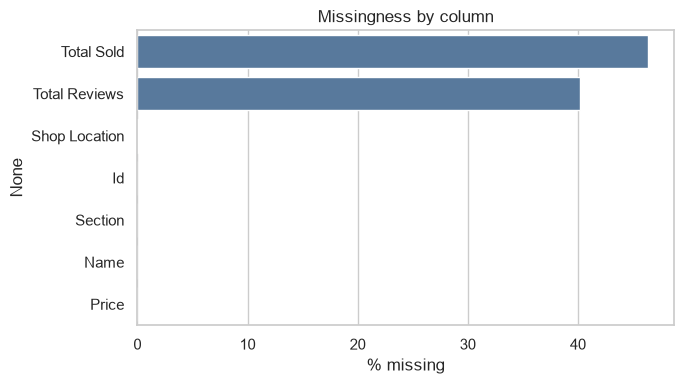

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=miss_pct.values, y=miss_pct.index, ax=ax, color='#4C78A8')
ax.set_xlabel('% missing')
ax.set_title('Missingness by column')
fig.tight_layout()
fig.savefig(FIGS / 'missingness.png', dpi=120)
plt.show()

## 3. Target — Price

Strip the `฿` prefix and any thousand separators → numeric. Distribution is right-skewed (median ฿290, max ฿5,600), so a `log1p` transform will help any regression model.

In [5]:
df['Price'] = pd.to_numeric(
    df['Price'].astype(str).str.replace('฿', '', regex=False).str.replace(',', '', regex=False),
    errors='coerce',
)
assert df['Price'].dtype != object
assert df['Price'].isna().sum() == 0
df['Price'].describe()

count    68499.000000
mean       509.184972
std        631.007660
min          9.000000
25%        159.000000
50%        290.000000
75%        590.000000
max       5600.000000
Name: Price, dtype: float64

/var/folders/z8/n13_r1ws7k57_fdtz3kwjmk00000gn/T/ipykernel_71662/1990363768.py:6: UserWarning: Glyph 3647 (\N{THAI CURRENCY SYMBOL BAHT}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/z8/n13_r1ws7k57_fdtz3kwjmk00000gn/T/ipykernel_71662/1990363768.py:7: UserWarning: Glyph 3647 (\N{THAI CURRENCY SYMBOL BAHT}) missing from font(s) Arial.
  fig.savefig(FIGS / 'price_dist.png', dpi=120)
/Users/akarapongmba/Documents/GitHub/hs-practical-machine-learning-final-project/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3647 (\N{THAI CURRENCY SYMBOL BAHT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


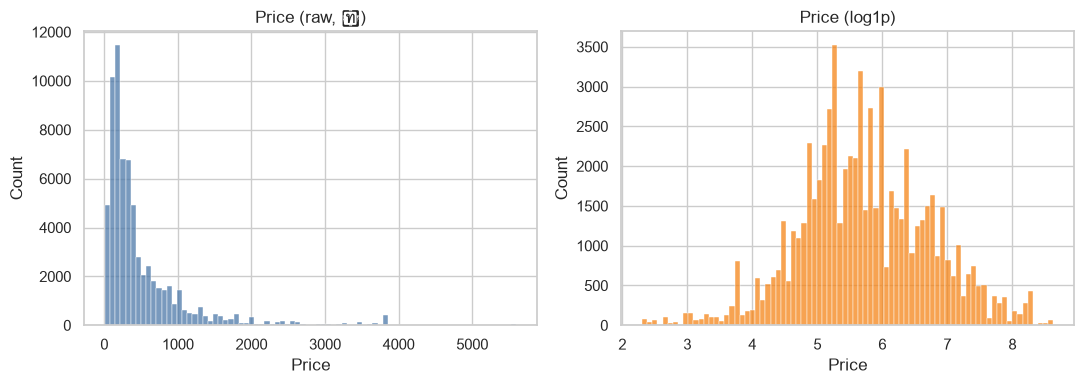

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['Price'], bins=80, ax=axes[0], color='#4C78A8')
axes[0].set_title('Price (raw, ฿)')
sns.histplot(np.log1p(df['Price']), bins=80, ax=axes[1], color='#F58518')
axes[1].set_title('Price (log1p)')
fig.tight_layout()
fig.savefig(FIGS / 'price_dist.png', dpi=120)
plt.show()

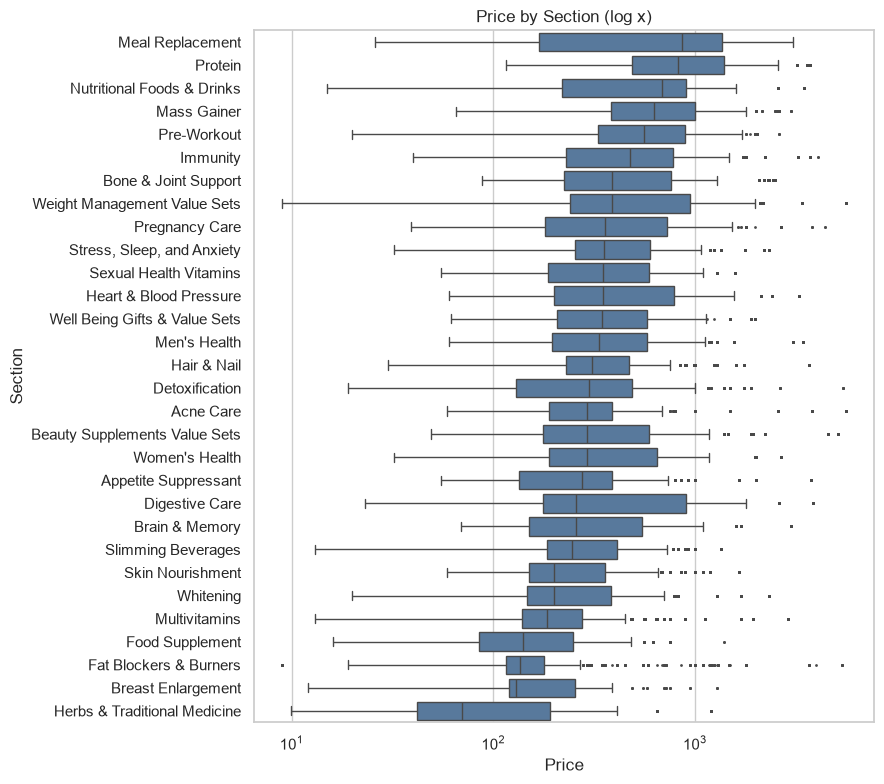

In [7]:
order = df.groupby('Section')['Price'].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(9, 8))
sns.boxplot(data=df, y='Section', x='Price', order=order, ax=ax,
            fliersize=1, color='#4C78A8')
ax.set_xscale('log')
ax.set_title('Price by Section (log x)')
fig.tight_layout()
fig.savefig(FIGS / 'price_by_section.png', dpi=120)
plt.show()

## 4. Categorical features

`Section` has 30 categories (balanced-ish, 640-4,160 rows each). `Shop Location` has 71 values (Bangkok dominates). `Name` is near-unique → not usable as a categorical feature as-is; it's the source for text/keyword features later.

In [8]:
print('Name unique:', df['Name'].nunique(), 'of', len(df))
df['Section'].value_counts()

Name unique: 2379 of 68499


Section
Skin Nourishment                 4160
Well Being Gifts & Value Sets    4080
Immunity                         4080
Multivitamins                    4040
Herbs & Traditional Medicine     4000
Bone & Joint Support             3960
Digestive Care                   3959
Slimming Beverages               3840
Protein                          3280
Whitening                        3200
Brain & Memory                   3040
Nutritional Foods & Drinks       2920
Appetite Suppressant             2440
Women's Health                   2240
Men's Health                     2200
Heart & Blood Pressure           2120
Weight Management Value Sets     2040
Detoxification                   1760
Fat Blockers & Burners           1720
Beauty Supplements Value Sets    1480
Pregnancy Care                   1320
Food Supplement                  1020
Sexual Health Vitamins            960
Pre-Workout                       920
Hair & Nail                       800
Acne Care                         760
Mass

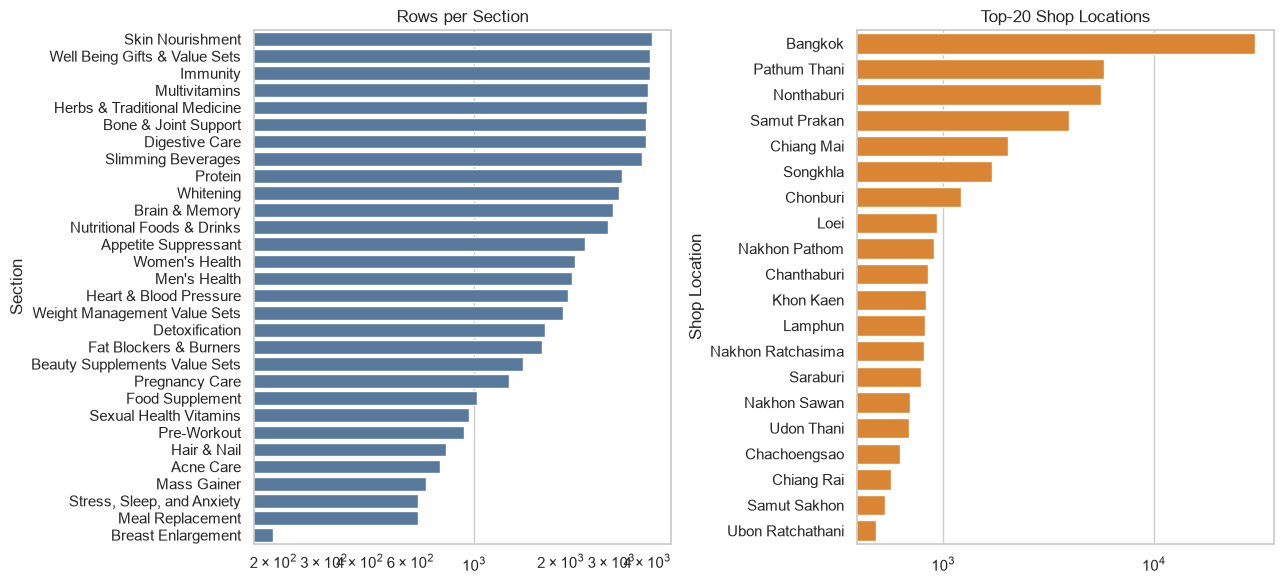

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
sec = df['Section'].value_counts()
sns.barplot(x=sec.values, y=sec.index, ax=axes[0], color='#4C78A8')
axes[0].set_title('Rows per Section')
axes[0].set_xscale('log')

loc = df['Shop Location'].value_counts().head(20)
sns.barplot(x=loc.values, y=loc.index, ax=axes[1], color='#F58518')
axes[1].set_title('Top-20 Shop Locations')
axes[1].set_xscale('log')
fig.tight_layout()
fig.savefig(FIGS / 'section_counts.png', dpi=120)
fig.savefig(FIGS / 'location_counts.png', dpi=120)
plt.show()

## 5. Price vs. features

First read on signal: `Section` clearly shifts price (e.g. value sets vs. single supplements). `Shop Location` effect is weaker but Bangkok/satellite provinces may differ from upcountry. Below: median price per section, and boxplots by the top locations.

In [10]:
agg = df.groupby('Section')['Price'].agg(['count', 'mean', 'median']).sort_values('median', ascending=False)
agg.round(1)

,count,mean,median
Section,,,
Meal Replacement,640,916.0,865.0
Protein,3280,1030.1,825.0
Nutritional Foods & Drinks,2920,747.1,689.0
Mass Gainer,680,763.6,630.0
Pre-Workout,920,645.4,560.0
Immunity,4080,664.8,479.0
Bone & Joint Support,3960,638.8,390.0
Weight Management Value Sets,2040,739.1,390.0
Pregnancy Care,1320,569.2,360.0


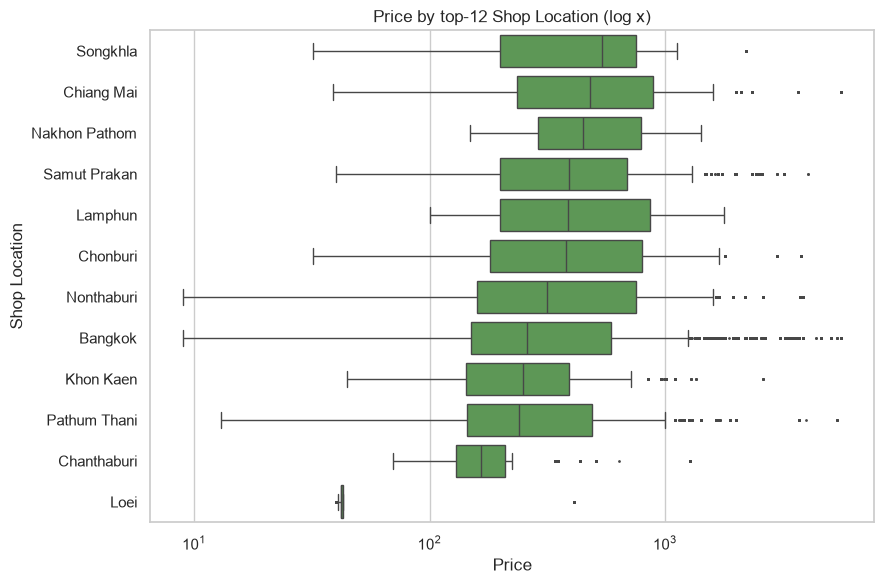

In [11]:
top_loc = df['Shop Location'].value_counts().head(12).index
sub = df[df['Shop Location'].isin(top_loc)]
fig, ax = plt.subplots(figsize=(9, 6))
order = sub.groupby('Shop Location')['Price'].median().sort_values(ascending=False).index
sns.boxplot(data=sub, y='Shop Location', x='Price', order=order, ax=ax,
            fliersize=1, color='#54A24B')
ax.set_xscale('log')
ax.set_title('Price by top-12 Shop Location (log x)')
fig.tight_layout()
fig.savefig(FIGS / 'price_by_location.png', dpi=120)
plt.show()

## 6. Findings & next steps

**Data quality**
- Parsing must use a real CSV reader (naive split corrupts `Section` and `Name` on commas). `"Stress, Sleep, and Anxiety"` is one category; `Section` has **30** cats.
- `Price`: `฿`-prefixed string → cleaned to float, 0 NaN. Right-skewed (median ฿290, max ฿5,600) → use `log1p` as the regression target.
- `Total Sold` is Thai text (`'7 ชิ้น'`) and ~46% missing; `Total Reviews` is `'(2)'`-style and ~40% missing. Both are weak — drop or use only as sparse signals.
- `Shop Location`: 71 values, 69 blanks, Bangkok-dominant.
- `Name`: near-unique (~one per row) — treat as text, not categorical.

**Features for price regression**
- Usable: `Section` (one-hot / target encoding), `Shop Location` (target encoding — high cardinality), text features from `Name` (TF-IDF / keyword indicators for brand, form, count).
- Drop: `Id` (identifier), `Total Sold`, `Total Reviews` (coverage).

**Preprocessing to build next**
1. `y = log1p(Price)`.
2. Encode `Section` (one-hot, only 30 cats) and `Shop Location` (target or count encoding, 71 cats).
3. Text features from `Name` — start with keyword/brand indicators before going full TF-IDF.
4. Baselines: Ridge on encoded cats → add text features → compare. Train/test split with `Section`-stratification.